<a href="https://colab.research.google.com/github/GautamiRavi/Ride-Price-detection/blob/main/ridefare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
distance_km=np.random.uniform(1,20,500)

actual_price=(distance_km*15)+40+np.random.normal(0,20,500)

uber_data=pd.DataFrame({
    'Distance_KM':distance_km,
    'Price_INR':actual_price
})

print("Here is our Uber Database:")
print(uber_data.head())

Here is our Uber Database:
   Distance_KM   Price_INR
0     8.116262  168.579053
1    19.063572  363.476994
2    14.907885  282.626750
3    12.374511  214.079595
4     3.964354   81.497019


The AI predicts a 10km ride will cost: {predicted_fare[0]:.2f}


Text(0, 0.5, 'Price(INR)')

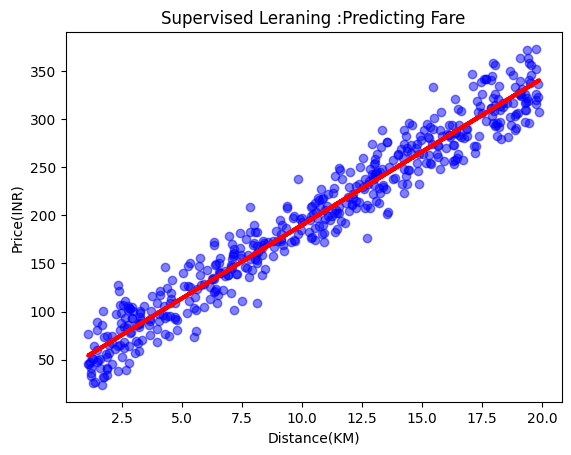

In [2]:
from sklearn.linear_model import LinearRegression

X=uber_data[['Distance_KM']]
y=uber_data[['Price_INR']]

price_model=LinearRegression()
price_model.fit(X,y)

new_ride=pd.DataFrame({'Distance_KM':[10]})
predicted_fare=price_model.predict(new_ride)

print("The AI predicts a 10km ride will cost: {predicted_fare[0]:.2f}")

plt.scatter(X,y,color='blue',alpha=0.5,label='Actual Past rides')
plt.plot(X,price_model.predict(X),color='red',linewidth=3,label='AI Logic Rule')
plt.title("Supervised Leraning :Predicting Fare")
plt.xlabel("Distance(KM)")
plt.ylabel("Price(INR)")


In [5]:
import random

surge_options=[1.0,1.5,2.0]

ai_memory_rewards=[0,0,0]

times_tried=[0,0,0]

print("Ai is learning the best surge price by trial and error...\n")

for ride in range (100):
  action_index=random.randint(0,2)
  chosen_surge=surge_options[action_index]

  if chosen_surge==1.0:
    reward=50
  elif chosen_surge==1.5:
    reward=75 if random.random()>0.2 else 0
  elif chosen_surge==2.0:
    reward=100 if random.random()>0.6 else 0

  ai_memory_rewards[action_index]+=reward
  times_tried[action_index]+=1

average_rewards=[ai_memory_rewards[i]/(times_tried[i]+1) for i in range(3)]

for i in range(3):
  print(f"surge{surge_options[i]}x earned an average of rupees{average_rewards[i]:.2f}per ride.")

best_action=surge_options[np.argmax(average_rewards)]
print(f"\nReinforcemet learning complete.AI sets final surge to:{best_action}x")

Ai is learning the best surge price by trial and error...

surge1.0x earned an average of rupees48.21per ride.
surge1.5x earned an average of rupees65.13per ride.
surge2.0x earned an average of rupees35.14per ride.

Reinforcemet learning complete.AI sets final surge to:1.5x


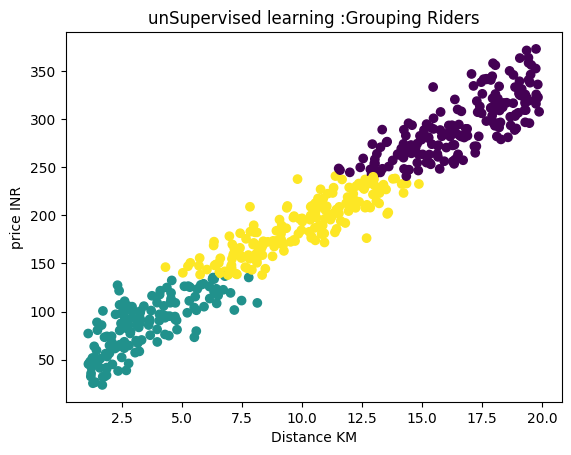

In [8]:
from sklearn.cluster import KMeans

data_for_clustering=uber_data[['Distance_KM','Price_INR']]

clustering_model=KMeans(n_clusters=3,random_state=42,n_init=10)
uber_data['Rider_Type']=clustering_model.fit_predict(data_for_clustering)

plt.scatter(uber_data['Distance_KM'],uber_data['Price_INR'],c=uber_data['Rider_Type'],cmap='viridis')
plt.title("unSupervised learning :Grouping Riders")
plt.xlabel("Distance KM")
plt.ylabel("price INR")

plt.show()